# Phase 4  Segmentation

**Goal:** Split users into meaningful groups to find who converts best and who doesn't.

By the end of this notebook you will know:
- How to segment by price tier, category, and brand
- How to build a user-level behavioral profile
- How to identify your best and worst customer segments
- How segmentation drives GTM targeting decisions

---

## Core Concept: Why Segment?

**Average metrics hide the truth.**

Example:
- Overall cart-to-purchase rate = 15%
- Budget products ($0–$50): cart-to-purchase = 35%
- Luxury products ($500+): cart-to-purchase = 3%

If you only look at the average (15%), you make decisions for no one.
If you segment, you discover: "our checkout works great for budget items but fails for luxury."

**Segmentation = finding which sub-groups behave differently, then acting on it.**

GTM teams use segmentation to:
- Focus ad spend on high-converting segments
- Fix the experience for low-converting segments
- Personalize messaging for different buyer types

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

df_full = pd.read_csv("../data/2019-Oct.csv")
all_user_ids = df_full["user_id"].unique()
sampled_users = pd.Series(all_user_ids).sample(n=50_000, random_state=42)
df = df_full[df_full["user_id"].isin(sampled_users)].copy()
df["event_time"] = pd.to_datetime(df["event_time"])
df["hour"]       = df["event_time"].dt.hour
df["day_of_week"] = df["event_time"].dt.dayofweek  # 0=Mon, 6=Sun

print("Data loaded.")

Data loaded.


## Segment 1  Price Tier

Create price buckets and compare conversion rates across them.

In [18]:
# Define price tiers
df["price_tier"] = pd.cut(
    df["price"],
    bins=[0, 50, 200, 500, 99_999],
    labels=["Budget ($0-50)", "Mid ($50-200)", "Premium ($200-500)", "Luxury ($500+)"]
)

# Funnel by price tier
tier_funnel = (
    df.groupby(["price_tier", "event_type"])["user_id"]
    .nunique()
    .unstack(fill_value=0)
)

# Ensure all columns exist
for col in ["view", "cart", "purchase"]:
    if col not in tier_funnel.columns:
        tier_funnel[col] = 0

tier_funnel["view_to_cart"]     = (tier_funnel["cart"]     / tier_funnel["view"]  * 100).round(1)
tier_funnel["cart_to_purchase"] = (tier_funnel["purchase"] / tier_funnel["cart"]  * 100).round(1)

print("PRICE TIER FUNNEL")
print(tier_funnel[["view", "cart", "purchase", "view_to_cart", "cart_to_purchase"]].to_string())

PRICE TIER FUNNEL
event_type           view  cart  purchase  view_to_cart  cart_to_purchase
price_tier                                                               
Budget ($0-50)      19391   775      1183           4.0             152.6
Mid ($50-200)       31031  2413      2640           7.8             109.4
Premium ($200-500)  25899  1880      1877           7.3              99.8
Luxury ($500+)      19030  1187      1076           6.2              90.6


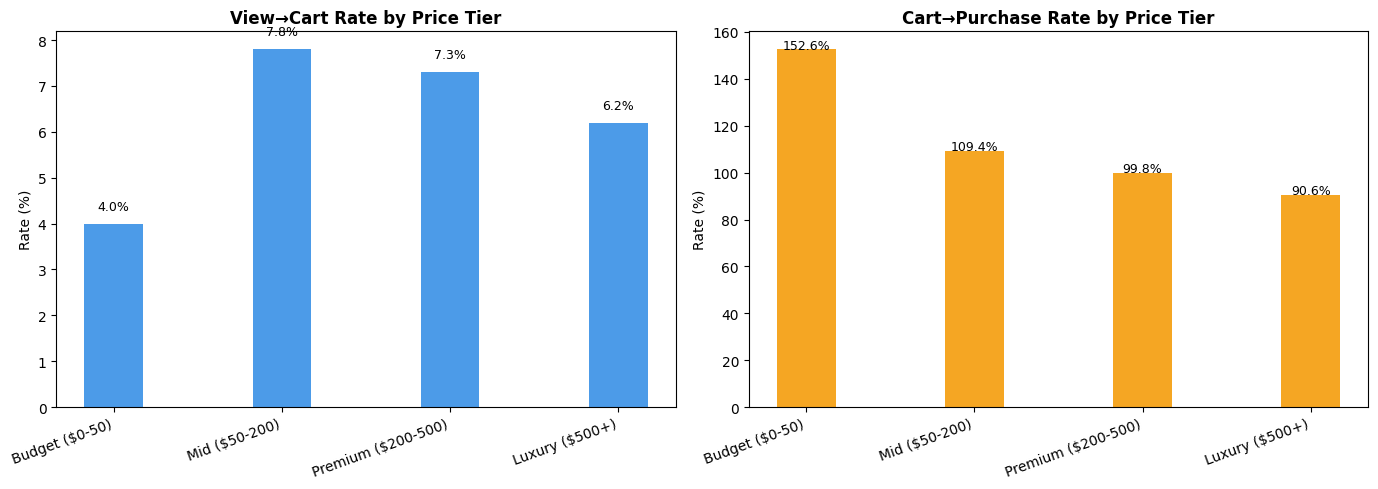


KEY QUESTION: Which price tier has the worst cart-to-purchase rate?
              That is where checkout improvements will have the most impact.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tiers  = tier_funnel.index.astype(str)
v2c    = tier_funnel["view_to_cart"].values
c2p    = tier_funnel["cart_to_purchase"].values
x      = np.arange(len(tiers))
width  = 0.35

axes[0].bar(x, v2c, width, color="#4C9BE8", label="View→Cart %")
axes[0].set_xticks(x)
axes[0].set_xticklabels(tiers, rotation=20, ha="right")
axes[0].set_title("View→Cart Rate by Price Tier", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Rate (%)")
for i, v in enumerate(v2c):
    axes[0].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

axes[1].bar(x, c2p, width, color="#F5A623", label="Cart→Purchase %")
axes[1].set_xticks(x)
axes[1].set_xticklabels(tiers, rotation=20, ha="right")
axes[1].set_title("Cart→Purchase Rate by Price Tier", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Rate (%)")
for i, v in enumerate(c2p):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/04_price_tier_funnel.png", dpi=150, bbox_inches="tight")
plt.show()
print()
print("KEY QUESTION: Which price tier has the worst cart-to-purchase rate?")
print("              That is where checkout improvements will have the most impact.")

## Segment 2  Brand Performance

Which brands drive the most conversions? Which are weak?

In [20]:
brand_df = df[df["brand"].notna()]

brand_funnel = (
    brand_df.groupby(["brand", "event_type"])["user_id"]
    .nunique()
    .unstack(fill_value=0)
)

for col in ["view", "cart", "purchase"]:
    if col not in brand_funnel.columns:
        brand_funnel[col] = 0

brand_funnel = brand_funnel[brand_funnel["view"] >= 500]  # min volume
brand_funnel["conversion_rate"] = (brand_funnel["purchase"] / brand_funnel["view"] * 100).round(2)
brand_funnel["volume_score"]    = brand_funnel["view"]
brand_funnel = brand_funnel.sort_values("conversion_rate", ascending=False)

print("TOP 10 BRANDS BY CONVERSION RATE")
print(brand_funnel[["view", "purchase", "conversion_rate"]].head(10).to_string())
print()
print("BOTTOM 10 BRANDS BY CONVERSION RATE")
print(brand_funnel[["view", "purchase", "conversion_rate"]].tail(10).to_string())

TOP 10 BRANDS BY CONVERSION RATE
event_type   view  purchase  conversion_rate
brand                                       
samsung     15548      1561            10.04
apple       11985      1079             9.00
xiaomi       7842       585             7.46
yokohama      606        39             6.44
triangle     1018        63             6.19
nokian        921        56             6.08
oppo         1958       115             5.87
huawei       3867       226             5.84
cordiant     1966       113             5.75
indesit      1220        70             5.74

BOTTOM 10 BRANDS BY CONVERSION RATE
event_type  view  purchase  conversion_rate
brand                                      
karcher      529        14             2.65
force       1093        25             2.29
skad         638        12             1.88
baden        685        10             1.46
brw          968        14             1.45
sv          1070        14             1.31
respect     1290        15            

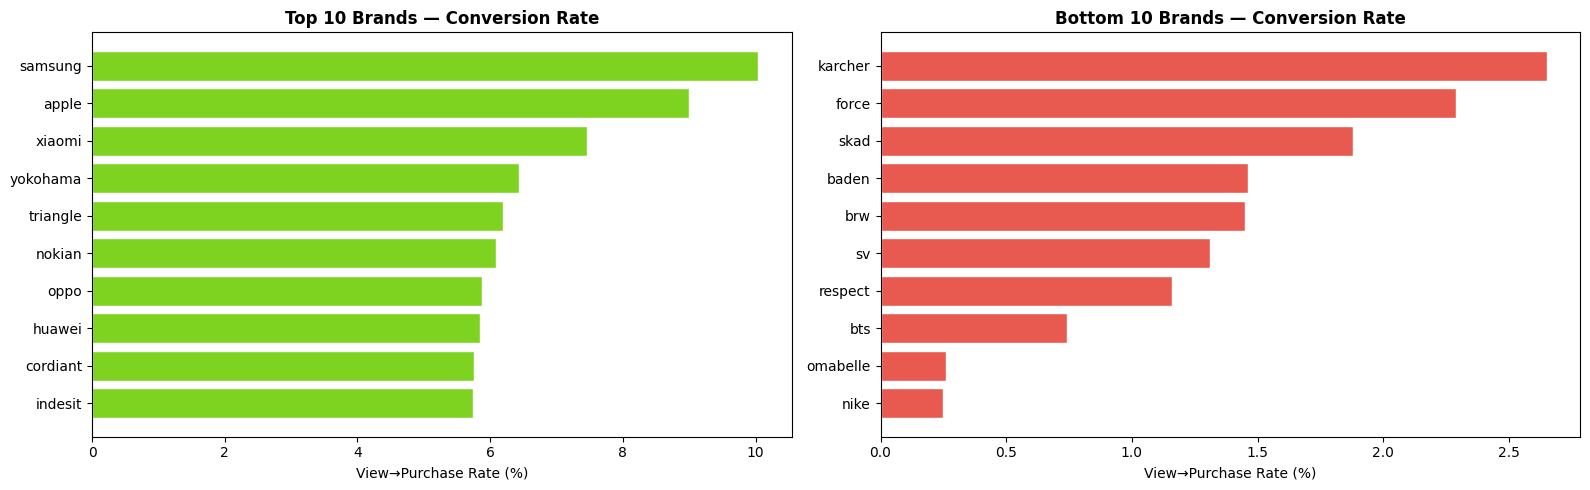

In [21]:
top_brands    = brand_funnel.head(10)
bottom_brands = brand_funnel.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top brands
axes[0].barh(range(len(top_brands)), top_brands["conversion_rate"],
             color="#7ED321", edgecolor="white")
axes[0].set_yticks(range(len(top_brands)))
axes[0].set_yticklabels(top_brands.index)
axes[0].set_title("Top 10 Brands  Conversion Rate", fontsize=12, fontweight="bold")
axes[0].set_xlabel("View→Purchase Rate (%)")
axes[0].invert_yaxis()

# Bottom brands
axes[1].barh(range(len(bottom_brands)), bottom_brands["conversion_rate"],
             color="#E85A4F", edgecolor="white")
axes[1].set_yticks(range(len(bottom_brands)))
axes[1].set_yticklabels(bottom_brands.index)
axes[1].set_title("Bottom 10 Brands  Conversion Rate", fontsize=12, fontweight="bold")
axes[1].set_xlabel("View→Purchase Rate (%)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("../outputs/04_brand_conversion.png", dpi=150, bbox_inches="tight")
plt.show()

## Segment 3  Day of Week

Do users buy more on weekdays or weekends? This shapes email and ad scheduling.

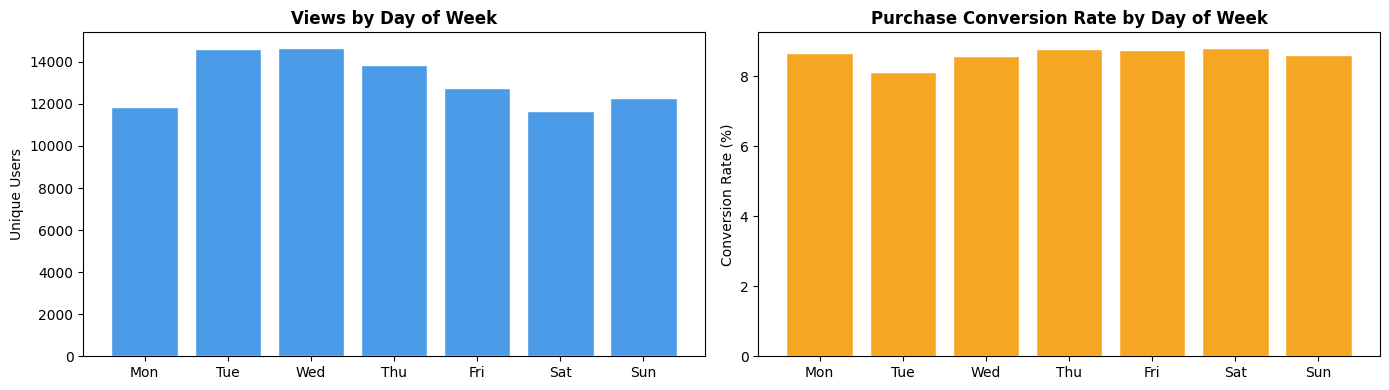

Best conversion day  : Sat  (8.81%)
Worst conversion day : Tue (8.12%)


In [22]:
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

day_views     = df[df["event_type"] == "view"].groupby("day_of_week")["user_id"].nunique()
day_purchases = df[df["event_type"] == "purchase"].groupby("day_of_week")["user_id"].nunique()
day_rate      = (day_purchases / day_views * 100).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(day_labels, day_views.reindex(range(7), fill_value=0).values,
            color="#4C9BE8", edgecolor="white")
axes[0].set_title("Views by Day of Week", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Unique Users")

axes[1].bar(day_labels, day_rate.reindex(range(7), fill_value=0).values,
            color="#F5A623", edgecolor="white")
axes[1].set_title("Purchase Conversion Rate by Day of Week", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Conversion Rate (%)")

plt.tight_layout()
plt.savefig("../outputs/04_day_of_week.png", dpi=150, bbox_inches="tight")
plt.show()

best_day  = day_rate.idxmax()
worst_day = day_rate.idxmin()
print(f"Best conversion day  : {day_labels[best_day]}  ({day_rate[best_day]:.2f}%)")
print(f"Worst conversion day : {day_labels[worst_day]} ({day_rate[worst_day]:.2f}%)")

## Segment 4  User Behavioral Profiles (RFM-style)

**RFM = Recency, Frequency, Monetary**

This is the gold standard of customer segmentation in GTM.

- **Recency**  When did the user last purchase?
- **Frequency**  How many times did they purchase?
- **Monetary**  How much did they spend?

We'll build a simplified version using events.

In [23]:
purchase_df = df[df["event_type"] == "purchase"].copy()
latest_date = df["event_time"].max()

user_profile = purchase_df.groupby("user_id").agg(
    total_purchases  = ("event_time", "count"),
    total_spend      = ("price", "sum"),
    avg_spend        = ("price", "mean"),
    last_purchase    = ("event_time", "max")
).reset_index()

user_profile["days_since_purchase"] = (
    (latest_date - user_profile["last_purchase"]).dt.days
)

print(f"Users with at least 1 purchase: {len(user_profile):,}")
print()
print("USER PROFILE STATISTICS:")
print(user_profile[["total_purchases", "total_spend", "avg_spend", "days_since_purchase"]]
      .describe().round(2))

Users with at least 1 purchase: 5,626

USER PROFILE STATISTICS:
       total_purchases  total_spend  avg_spend  days_since_purchase
count          5626.00      5626.00    5626.00              5626.00
mean              2.08       632.81     283.76                13.70
std               3.29      1644.39     315.57                 8.69
min               1.00         1.67       1.67                 0.00
25%               1.00       112.47      86.02                 6.00
50%               1.00       250.52     174.52                13.00
75%               2.00       623.07     340.70                21.00
max             111.00     46339.58    2574.04                30.00


In [24]:
# Segment users into tiers
user_profile["spend_tier"] = pd.qcut(
    user_profile["total_spend"],
    q=3,
    labels=["Low Spender", "Mid Spender", "High Spender"]
)

tier_summary = user_profile.groupby("spend_tier").agg(
    user_count   = ("user_id", "count"),
    avg_spend    = ("total_spend", "mean"),
    avg_orders   = ("total_purchases", "mean")
).round(2)

print("SPEND TIER BREAKDOWN")
print(tier_summary.to_string())
print()
print("GTM IMPLICATION:")
print("  High Spenders  → Loyalty program, early access, premium support")
print("  Mid Spenders   → Upsell campaigns, bundle deals")
print("  Low Spenders   → Re-engagement emails, first-time buyer discounts")

SPEND TIER BREAKDOWN
              user_count  avg_spend  avg_orders
spend_tier                                     
Low Spender         1877      74.46        1.19
Mid Spender         1874     259.36        1.46
High Spender        1875    1565.00        3.58

GTM IMPLICATION:
  High Spenders  → Loyalty program, early access, premium support
  Mid Spenders   → Upsell campaigns, bundle deals
  Low Spenders   → Re-engagement emails, first-time buyer discounts


## Checkpoint

1. What is the definition of segmentation in GTM analysis?
2. Why is looking at averages alone misleading?
3. Which price tier showed the lowest cart-to-purchase rate?
4. What is RFM and what does each letter stand for?
5. If you identified "High Spenders" in the data, what GTM action would you take for them?

---
➡️ Next: `05_recommendations.ipynb`